<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200"/>
</p></center>

<center><font size=10>AI Agents for Business Applications</center></font>
<center><font size=6>Week 3 - Planning and Reasoning</center></font>

<center><p float="center">
  <img src="https://images.pexels.com/photos/28682356/pexels-photo-28682356.jpeg" width="640"/>
</p></center>

<center><font size=6>Financial Compliance Agent for Trade Surveillance
</center></font>

## **Problem Statement**

### Business Context

A mid-sized financial institution must monitor insider trading to comply with SEC regulations and internal policies. Corporate insiders (executives, directors, and 10%+ shareholders) are required to report trades through SEC Forms 3, 4, and 5 within two business days. Compliance teams currently review thousands of insider trades manually each quarter. This requires checking SEC EDGAR filings, internal authorization limits, and historical trading records, while also maintaining clear audit trails for regulators.

Traditional rule-based surveillance systems rely on basic thresholds and generate 60-70% false positives because they lack context. They cannot analyze an insider's full trading history, detect complex timing patterns (such as trades before earnings announcements), or clearly explain why a transaction was flagged. As a result, compliance teams spend most of their time investigating false alerts and may miss more sophisticated violations.

A simple rule-based or classification system is insufficient because regulatory compliance requires transparent, explainable, multi-step reasoning backed by data from multiple sources. The institution needs an AI-powered compliance agent that can:
* automatically collect and combine data from SEC EDGAR and internal systems
* apply role-based trading limits and compliance rules with clear reasoning
* detect complex patterns across multiple transactions and time windows
* validate findings across multiple sources to reduce false positives
* produce clear, audit-ready investigation reports with full evidence trails

### Objective

The objective is to build an agentic compliance investigation system that automates the end-to-end analysis of transactional disclosures from SEC EDGAR data to accurately differentiate legitimate regulatory violations from false positives. The system applies systematic compliance evaluation using role-based authorization frameworks, historical pattern analysis, quarterly volume tracking, and timing anomaly detection. It generates audit-ready investigation reports with complete evidence chains, grounded in verifiable data and clear, regulator-friendly explanations.

The solution is designed to operate at scale, supporting high-throughput investigations with strong reliability and full audit-trail preservation, while maintaining explainability by exposing the agent's step-by-step reasoning so compliance officers can validate every decision.

The end goal is to

* achieve high-accuracy automated violation detection while minimizing false positives
* enforce consistent compliance evaluation through structured rules, historical analysis, and anomaly detection
* produce audit-ready, regulator-verifiable reports with complete evidence chains
* support large-scale processing with high throughput, reliability, and audit-trail integrity, and
* enable full explainability by making the agent's reasoning process transparent to compliance teams

### Data Description

Real SEC Form 4 filings data. Corporate insiders must report stock trades within 2 business days. Data includes executive roles, transaction details, and ownership info.

 **Files Used** (TSV format):

 1. **SUBMISSION.tsv** - Filing metadata
    - ACCESSION_NUMBER (unique filing ID)
    - FILING_DATE, PERIOD_OF_REPORT
    - ISSUERCIK, ISSUERNAME, ISSUERTRADINGSYMBOL (company info)
    - FORM4_TRANS_REPORTED (number of transactions)

 2. **REPORTINGOWNER.tsv** - Insider details
    - ACCESSION_NUMBER (links to submission)
    - RPTOWNERCIK, RPTOWNERNAME (insider identity)
    - RPTOWNER_RELATIONSHIP (relationship flags as pipe-separated string)
    - RPTOWNER_TITLE (e.g., "CEO", "CFO", "Director")

 3. **NONDERIV_TRANS.tsv** - Stock transaction details (non-derivative)
    - ACCESSION_NUMBER (links to submission)
    - TRANS_DATE, TRANS_CODE (P=Purchase, S=Sale, A=Award, etc.)
    - TRANS_SHARES, TRANS_PRICEPERSHARE
    - TRANS_ACQUIRED_DISP_CD (A=Acquired, D=Disposed)
    - SHRS_OWND_FOLWNG_TRANS (shares owned after transaction)

**File Used** (DB format):

1. **role_limits** - Role-based authorization and trading limits

   - role_type (e.g., CEO, CFO, Director, VP, Default)
   - authorization_level (hierarchical access level)
   - single_trade_limit (maximum value per transaction)
   - quarterly_limit (maximum cumulative value over 90 days)
   - blackout_restrictions (blackout or timing constraints)

2. **compliance_rules** - Regulatory and internal compliance rules

   - rule_id (unique rule identifier)
   - rule_name (human-readable rule name)
   - threshold_value (numeric threshold, if applicable)
   - rule_type (limit-based, pattern-based, timing-based)
   - severity (violation severity level)
   - description (rule explanation and intent)



## **Solution Approach**

This solution implements an agentic workflow to automate insider-trading investigations using SEC EDGAR data. The system combines planning, multi-step reasoning, validation, and orchestration to produce explainable, audit-ready compliance decisions at scale.

**Investigation Flow**

* A **Planner Agent** receives a flagged SEC accession number and decomposes the investigation into structured steps before any data is queried.
* The **Investigation Agent** follows a **Reason -> Act -> Observe** loop to collect and analyze evidence from SEC EDGAR datasets:

  * **SUBMISSION** (filing and issuer details)
  * **REPORTINGOWNER** (insider identity and role)
  * **NONDERIV_TRANS** (transaction details)
* The agent applies role-based limits, historical trading analysis, quarterly volume checks, and timing anomaly detection using dedicated tools.
* A **Validator Agent** cross-checks all conclusions against retrieved data, flags unsupported assumptions, and assigns a confidence score.
* The system generates an **audit-ready report** with findings, evidence chains, compliance assessment, and recommended actions.


The system uses **LangGraph** to orchestrate the end-to-end workflow, maintaining state, enabling conditional routing, and preserving a complete audit trail.

## **Installing and Importing Necessary Libraries and Dependencies**

In [ ]:
!pip install langchain==1.1.3\
langchain_openai==1.1.3 \
langgraph==1.0.4 \
openai==2.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.3/157.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.16.0
    Uninstalling openai-2.16.0:
      Successfully uninstalled openai-2.16.0
  Attempting uninstall: langgraph-sdk
    Found existing installation: langgraph-sdk 0.3.3
    Uninstalling langgraph-sdk-0.3.3:
      Successfully uninstalled langgraph-sdk-0.3.3
  Attempting uninstall: langgraph-checkpoint
    Found existing installation: langgraph-checkpoint 4.0.0
    Uninstalling langgraph-checkpoint-4.0.0:
      Successfully uninstalled langgraph-ch

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from typing import TypedDict, Annotated, Sequence
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
import random
import sqlite3

## **Data Loading and Model Initialization**


### OpenAI API Calling



In [ ]:
# Load the JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary
    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                                             # Extract the API key from the config
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")

# Store API credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                  # Set API key as environment variable
os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE                                 # Set API base URL as environment variable

For the problem at hands, we will use two LLMs to separate responsibilities
- a lightweight model for primary reasoning and generation, and
- a more complex model for evaluation and validation, ensuring better accuracy, reliability, and cost efficiency.


In [ ]:
# Initialize LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Initialize separate LLM for validation (more powerful model)
llm_validator = ChatOpenAI(model="gpt-4o", temperature=0)

### Data Loading (.tsv)

#### Load SEC EDGAR Insider Trading Datasets

In [ ]:
submissions_df = pd.read_csv('SUBMISSION.tsv', sep='\t', low_memory=False)
owners_df = pd.read_csv('REPORTINGOWNER.tsv', sep='\t', low_memory=False)
transactions_df = pd.read_csv('NONDERIV_TRANS.tsv', sep='\t', low_memory=False)

#### Inspect Dataset Sizes

In [ ]:
print(f"   Submissions: {len(submissions_df):,} filings")
print(f"   Reporting Owners: {len(owners_df):,} records")
print(f"   Transactions: {len(transactions_df):,} trades")

   Submissions: 35,457 filings
   Reporting Owners: 39,104 records
   Transactions: 55,125 trades


#### Preview Sample Records

In [ ]:
submissions_df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,ACCESSION_NUMBER,FILING_DATE,PERIOD_OF_REPORT,DATE_OF_ORIG_SUB,NO_SECURITIES_OWNED,NOT_SUBJECT_SEC16,FORM3_HOLDINGS_REPORTED,FORM4_TRANS_REPORTED,DOCUMENT_TYPE,ISSUERCIK,ISSUERNAME,ISSUERTRADINGSYMBOL,REMARKS,AFF10B5ONE
0,0001393311-25-000124,31-JUL-2025,30-JUL-2025,NaN,NaN,0,NaN,NaN,4,1393311,Public Storage,PSA,NaN,0
1,0001437749-25-024154,31-JUL-2025,31-JUL-2025,NaN,0.0,NaN,NaN,NaN,3,2058758,"Avidia Bancorp, Inc.",AVBC,NaN,NaN
2,0001609253-25-000063,31-JUL-2025,29-JUL-2025,NaN,NaN,0,NaN,NaN,4,1609253,California Resources Corp,CRC,NaN,0
3,0001562180-25-005601,31-JUL-2025,29-JUL-2025,NaN,NaN,false,NaN,NaN,4,1667011,"Arteris, Inc.",AIP,NaN,true
4,0001437749-25-024193,31-JUL-2025,31-JUL-2025,NaN,0.0,NaN,NaN,NaN,3,2036060,"Security Midwest Bancorp, Inc.",SBMW,NaN,NaN


In [ ]:
owners_df.head()

,ACCESSION_NUMBER,RPTOWNERCIK,RPTOWNERNAME,RPTOWNER_RELATIONSHIP,RPTOWNER_TITLE,RPTOWNER_TXT,RPTOWNER_STREET1,RPTOWNER_STREET2,RPTOWNER_CITY,RPTOWNER_STATE,RPTOWNER_ZIPCODE,RPTOWNER_STATE_DESC,FILE_NUMBER
0,0001437749-25-030143,1909177,Woelfel Jessica,Officer,"GC, CCO, and CS",NaN,"C/O ORMAT TECHNOLOGIES, INC.",6884 SIERRA CENTER PARKWAY,RENO,NV,89511,NaN,001-32347
1,0001437749-25-030142,1571480,Blachar Doron,Officer,Chief Executive Officer,NaN,"C/O ORMAT TECHNOLOGIES, INC.",6884 SIERRA CENTER PARKWAY,RENO,NV,89511,NaN,001-32347
2,0001437749-25-030141,1098567,STERN STANLEY,Director,NaN,NaN,"C/O ORMAT TECHNOLOGIES, INC.",6884 SIERRA CENTER PARKWAY,RENO,NV,89511,NaN,001-32347
3,0001213900-25-094292,2076481,Zhang Lili,Director,NaN,NaN,"C/O ZHONG GUO LIANG TOU GRP LTD, RM 2712","ZHUHAI CENTER BLDING, NO. 1663 YINWAN RD",ZHUHAI,F4,519000,CHINA,001-41898
4,0001213900-25-094291,2076533,Jiang Zhenjun,"Director,Officer,TenPercentOwner",Chairman of the Board and CEO,NaN,"C/O ZHONG GUO LIANG TOU GRP LTD, RM 2712","ZHUHAI CENTER BLDING, NO. 1663 YINWAN RD",ZHUHAI,NY,519000,NaN,001-41898


In [ ]:
transactions_df.head()

,ACCESSION_NUMBER,NONDERIV_TRANS_SK,SECURITY_TITLE,SECURITY_TITLE_FN,TRANS_DATE,TRANS_DATE_FN,DEEMED_EXECUTION_DATE,DEEMED_EXECUTION_DATE_FN,TRANS_FORM_TYPE,TRANS_CODE,...,TRANS_ACQUIRED_DISP_CD,TRANS_ACQUIRED_DISP_CD_FN,SHRS_OWND_FOLWNG_TRANS,SHRS_OWND_FOLWNG_TRANS_FN,VALU_OWND_FOLWNG_TRANS,VALU_OWND_FOLWNG_TRANS_FN,DIRECT_INDIRECT_OWNERSHIP,DIRECT_INDIRECT_OWNERSHIP_FN,NATURE_OF_OWNERSHIP,NATURE_OF_OWNERSHIP_FN
0,0001437749-25-030143,8775063,Common Stock,NaN,29-SEP-2025,NaN,NaN,NaN,4,S,...,D,NaN,3433.0,NaN,NaN,NaN,D,NaN,NaN,NaN
1,0001437749-25-030143,8775062,Common Stock,NaN,29-SEP-2025,NaN,NaN,NaN,4,D,...,D,NaN,7934.0,NaN,NaN,NaN,D,NaN,NaN,NaN
2,0001437749-25-030143,8775061,Common Stock,NaN,29-SEP-2025,NaN,NaN,NaN,4,M,...,A,NaN,15234.0,NaN,NaN,NaN,D,NaN,NaN,NaN
3,0001437749-25-030143,8775060,Common Stock,NaN,29-SEP-2025,NaN,NaN,NaN,4,D,...,D,NaN,6344.0,NaN,NaN,NaN,D,NaN,NaN,NaN
4,0001437749-25-030143,8775059,Common Stock,NaN,29-SEP-2025,NaN,NaN,NaN,4,M,...,A,NaN,11635.0,NaN,NaN,NaN,D,NaN,NaN,NaN


### Data Preprocessing (.tsv)

#### Standardize Date Fields

Convert filing and transaction dates into a consistent datetime format so the agent can perform time-based analysis such as recent activity checks and quarterly limit evaluation.

In [ ]:
# Data preprocessing
submissions_df['FILING_DATE'] = pd.to_datetime(
    submissions_df['FILING_DATE'],
    format='%Y-%m-%d',
    errors='coerce'
)

transactions_df['TRANS_DATE'] = pd.to_datetime(
    transactions_df['TRANS_DATE'],
    format='%Y-%m-%d',
    errors='coerce'
)

#### Compute Transaction Value

Calculate the total monetary value of each trade, which serves as the primary metric for role-based limit checks and compliance evaluation.

In [ ]:
transactions_df['TRANS_VALUE'] = transactions_df['TRANS_SHARES'] * transactions_df['TRANS_PRICEPERSHARE']

#### Create a Unified Transaction Dataset

Merge filings, insider details, and transaction records into a single dataset to enable end-to-end investigation and agent querying.

In [ ]:
# Create merged dataset for easier querying
merged_df = transactions_df.merge(submissions_df, on='ACCESSION_NUMBER', how='left')
merged_df = merged_df.merge(owners_df, on='ACCESSION_NUMBER', how='left')

#### Sample Transactions for Validation

Select a small, reproducible sample to quickly validate preprocessing logic before running large-scale investigations.

In [ ]:
# Sample some transactions for testing
sample_transactions = merged_df.sample(n=min(10, len(merged_df)), random_state=42)

Inspect sample records to confirm that insider identity, role, and transaction values are correctly populated.

In [ ]:
print("\n=== SAMPLE INSIDER TRANSACTIONS ===")
print(sample_transactions[['ACCESSION_NUMBER', 'RPTOWNERNAME', 'RPTOWNER_TITLE',
                           'ISSUERTRADINGSYMBOL', 'TRANS_CODE', 'TRANS_SHARES',
                           'TRANS_VALUE']].head(5).to_string(index=False))



=== SAMPLE INSIDER TRANSACTIONS ===
    ACCESSION_NUMBER          RPTOWNERNAME                 RPTOWNER_TITLE ISSUERTRADINGSYMBOL TRANS_CODE  TRANS_SHARES  TRANS_VALUE
0001647430-25-000003          Montano Juan EVP, CHIEF MTG BANKING OFFICER               RBCAA          S       1223.23   92390.5619
0001510281-25-000400        Weinstein Boaz                            NaN                 PEO          S      13627.00  300202.8100
0001062993-25-015343         Ozgen Mustafa  Pres, Devices, Prod, and Tech                ROKU          F       4605.00  441435.3000
0001641172-25-019935 Hillis Dustin Michael     Pres & Chief Strat Officer                SSGC          P     122500.00   51450.0000
0001599901-25-000188       McCarthy Teresa  Chief Human Resources Officer                 RNA          S      15000.00  621150.0000


Examine the range and central tendency of transaction values to contextualize thresholds and identify potential outliers.

In [ ]:
print(f"\n=== TRANSACTION VALUE STATISTICS ===")
print(f"Min: ${merged_df['TRANS_VALUE'].min():,.2f}")
print(f"Max: ${merged_df['TRANS_VALUE'].max():,.2f}")
print(f"Mean: ${merged_df['TRANS_VALUE'].mean():,.2f}")
print(f"Median: ${merged_df['TRANS_VALUE'].median():,.2f}")


=== TRANSACTION VALUE STATISTICS ===
Min: $0.00
Max: $307,763,430,923,520.00
Mean: $5,024,534,448.48
Median: $88,562.70


### Data Loading (.db)

Verify that the compliance database is available and ready for role-based authorization checks.

In [ ]:
db_path = 'compliance_data.db'

# Ensure database exists
if not os.path.exists(db_path):
    raise FileNotFoundError(
        "Compliance database not found. "
        "Please run setup_compliance_database.py first."
    )

# Connect to database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Minimal safety check for required table
cursor.execute(
    "SELECT name FROM sqlite_master WHERE type='table' AND name='role_limits'"
)
assert cursor.fetchone() is not None, "role_limits table missing"

print(" Compliance database connected and verified")

 Compliance database connected and verified


## **Tool Definitions**

In this section, we define the tools the agent can use to retrieve grounded evidence from SEC datasets and the compliance database during an investigation.

All database queries are intentionally hardcoded and parameterized to ensure the agent can only access verified data sources and exact fields, preventing hallucination and guaranteeing that every conclusion is backed by authoritative records.

### Retrieve Transaction Details from SEC Form 4

This tool fetches all relevant details for a specific insider transaction, including insider identity, company, shares, price, and transaction value.

In [ ]:
@tool
def get_transaction_details(accession_number: str) -> str:
    """
    Retrieve complete transaction details from SEC Form 4 filing.

    Args:
        accession_number: SEC filing identifier (e.g., '0001234567-24-000001')

    Returns:
        JSON with transaction details including insider info, shares, price, value
    """
    txn = merged_df[merged_df['ACCESSION_NUMBER'] == accession_number]

    if txn.empty:
        return json.dumps({'error': f'Transaction {accession_number} not found in database'})

    record = txn.iloc[0]
    result = {
        'accession_number': str(record['ACCESSION_NUMBER']),
        'filing_date': str(record['FILING_DATE']),
        'transaction_date': str(record['TRANS_DATE']),
        'insider_name': str(record['RPTOWNERNAME']),
        'insider_cik': str(record['RPTOWNERCIK']),
        'insider_title': str(record['RPTOWNER_TITLE']),
        'company_name': str(record['ISSUERNAME']),
        'ticker': str(record['ISSUERTRADINGSYMBOL']),
        'transaction_code': str(record['TRANS_CODE']),
        'transaction_type': 'Sale' if record['TRANS_CODE'] == 'S' else 'Purchase' if record['TRANS_CODE'] == 'P' else 'Other',
        'shares': float(record['TRANS_SHARES']),
        'price_per_share': float(record['TRANS_PRICEPERSHARE']),
        'transaction_value': float(record['TRANS_VALUE']),
        'shares_owned_after': float(record['SHRS_OWND_FOLWNG_TRANS'])
    }

    return json.dumps(result, indent=2)

### Retrieve Insider Authorization and Trading Limits

This tool maps an insider's job title to role-based authorization levels and trading limits stored in the compliance database.

In [ ]:
@tool
def get_insider_authorization(insider_title: str) -> str:
    """
    Retrieve authorization level and trading limits from SQLite database.

    Business Logic:
    - Matches insider title to role_limits table
    - Uses exact match first, then partial match, finally defaults to 'Default'
    - Hard-coded SQL ensures security and prevents injection attacks
    Args:
        insider_title: Job title (e.g., 'Chief Executive Officer', 'Director')

    Returns:
        JSON with authorization level and trading limits
    """
    conn = sqlite3.connect('compliance_data.db')
    cursor = conn.cursor()

    # Try exact match first
    cursor.execute('''
        SELECT role_type, authorization_level, single_trade_limit,
               quarterly_limit, blackout_restrictions
        FROM role_limits
        WHERE role_type = ?
    ''', (insider_title,))

    result = cursor.fetchone()

    # Try partial match if no exact match
    if not result:
        cursor.execute('''
            SELECT role_type, authorization_level, single_trade_limit,
                   quarterly_limit, blackout_restrictions
            FROM role_limits
            WHERE ? LIKE '%' || role_type || '%'
        ''', (insider_title,))
        result = cursor.fetchone()

    # Use default if still no match
    if not result:
        cursor.execute('''
            SELECT role_type, authorization_level, single_trade_limit,
                   quarterly_limit, blackout_restrictions
            FROM role_limits
            WHERE role_type = 'Default'
        ''')
        result = cursor.fetchone()

    conn.close()

    response = {
        'insider_title': insider_title,
        'matched_role': result[0],
        'authorization_level': result[1],
        'single_trade_limit': result[2],
        'quarterly_trade_limit': result[3],
        'blackout_restrictions': result[4],
        'currency': 'USD'
    }

    return json.dumps(response, indent=2)

### Retrieve Compliance Rules and Severity Levels

This tool loads all compliance rules used to evaluate violations and assign severity during validation.

In [ ]:
@tool
def get_compliance_rules() -> str:
    """
    Retrieve all compliance rules from SQLite database.

    Returns:
        JSON array of compliance rules with severity levels
    """
    conn = sqlite3.connect('compliance_data.db')
    cursor = conn.cursor()

    cursor.execute('''
        SELECT rule_id, rule_name, threshold_value, rule_type, severity
        FROM compliance_rules
        ORDER BY severity DESC
    ''')

    results = cursor.fetchall()
    conn.close()

    rules_list = []
    for row in results:
        rules_list.append({
            'rule_id': row[0],
            'rule_name': row[1],
            'threshold_value': row[2],
            'rule_type': row[3],
            'severity': row[4]
        })

    return json.dumps(rules_list, indent=2)

### Calculate Quarterly Trading Volume

This tool computes an insider's total trading activity over the last 90 days to detect quarterly limit breaches.

In [ ]:
@tool
def calculate_quarterly_trading_volume(insider_cik: str, end_date: str) -> str:
    """
    Calculate total trading volume for an insider over past 90 days.

    Args:
        insider_cik: Insider's CIK identifier
        end_date: End date in 'YYYY-MM-DD' format

    Returns:
        JSON with quarterly volume breakdown
    """
    end = pd.to_datetime(end_date)
    start = end - timedelta(days=90)

    insider_txns = merged_df[
        (merged_df['RPTOWNERCIK'] == insider_cik) &
        (merged_df['TRANS_DATE'] >= start) &
        (merged_df['TRANS_DATE'] <= end)
    ].copy()

    if insider_txns.empty:
        return json.dumps({
            'insider_cik': insider_cik,
            'quarter_start': str(start.date()),
            'quarter_end': str(end.date()),
            'total_volume': 0,
            'sales_volume': 0,
            'purchases_volume': 0,
            'transaction_count': 0,
            'message': 'No transactions found in this quarter'
        })

    sales = insider_txns[insider_txns['TRANS_CODE'] == 'S']
    purchases = insider_txns[insider_txns['TRANS_CODE'] == 'P']

    result = {
        'insider_cik': insider_cik,
        'insider_name': str(insider_txns['RPTOWNERNAME'].iloc[0]),
        'quarter_start': str(start.date()),
        'quarter_end': str(end.date()),
        'total_volume': float(insider_txns['TRANS_VALUE'].sum()),
        'sales_volume': float(sales['TRANS_VALUE'].sum()) if not sales.empty else 0,
        'purchases_volume': float(purchases['TRANS_VALUE'].sum()) if not purchases.empty else 0,
        'transaction_count': len(insider_txns),
        'sale_count': len(sales),
        'purchase_count': len(purchases),
        'transactions': insider_txns['ACCESSION_NUMBER'].tolist()
    }

    return json.dumps(result, indent=2)


### Analyze Historical Trading Patterns

This tool examines recent insider trading history to identify unusual frequency, value spikes, or inconsistent patterns.

In [ ]:
@tool
def search_insider_trading_history(insider_cik: str, transaction_code: str, lookback_days: int = 180) -> str:
    """
    Search historical trading patterns for an insider.

    Args:
        insider_cik: Insider's CIK identifier
        transaction_code: 'S' for Sales, 'P' for Purchases, or 'ALL'
        lookback_days: Number of days to look back (default: 180)

    Returns:
        JSON with historical trading pattern analysis
    """
    cutoff_date = pd.Timestamp.now() - timedelta(days=lookback_days)

    if transaction_code == 'ALL':
        history = merged_df[
            (merged_df['RPTOWNERCIK'] == insider_cik) &
            (merged_df['TRANS_DATE'] >= cutoff_date)
        ]
    else:
        history = merged_df[
            (merged_df['RPTOWNERCIK'] == insider_cik) &
            (merged_df['TRANS_CODE'] == transaction_code) &
            (merged_df['TRANS_DATE'] >= cutoff_date)
        ]

    if history.empty:
        return json.dumps({
            'insider_cik': insider_cik,
            'transaction_code': transaction_code,
            'lookback_days': lookback_days,
            'match_count': 0,
            'message': 'No matching transactions found'
        })

    # Get transaction details
    txns = history.sort_values('TRANS_DATE', ascending=False).head(10)
    transactions_list = []

    for _, row in txns.iterrows():
        transactions_list.append({
            'accession_number': str(row['ACCESSION_NUMBER']),
            'date': str(row['TRANS_DATE']),
            'code': str(row['TRANS_CODE']),
            'shares': float(row['TRANS_SHARES']),
            'value': float(row['TRANS_VALUE']),
            'ticker': str(row['ISSUERTRADINGSYMBOL'])
        })

    result = {
        'insider_cik': insider_cik,
        'insider_name': str(history['RPTOWNERNAME'].iloc[0]),
        'transaction_code': transaction_code,
        'lookback_days': lookback_days,
        'total_transactions': len(history),
        'total_value': float(history['TRANS_VALUE'].sum()),
        'avg_transaction_value': float(history['TRANS_VALUE'].mean()),
        'max_transaction_value': float(history['TRANS_VALUE'].max()),
        'recent_transactions': transactions_list
    }

    return json.dumps(result, indent=2)

### Register Tools for Agent Use

All tools are registered so the agent can invoke them dynamically during reasoning and investigation.

In [ ]:
# Collect all tools
tools = [
    get_transaction_details,
    get_insider_authorization,
    calculate_quarterly_trading_volume,
    search_insider_trading_history,
    get_compliance_rules
]

print("\n=== TOOLS REGISTERED ===")
for t in tools:
    print(f"  ✓ {t.name}: {t.description.split('.')[0]}")


=== TOOLS REGISTERED ===
  ✓ get_transaction_details: Retrieve complete transaction details from SEC Form 4 filing
  ✓ get_insider_authorization: Retrieve authorization level and trading limits from SQLite database
  ✓ calculate_quarterly_trading_volume: Calculate total trading volume for an insider over past 90 days
  ✓ search_insider_trading_history: Search historical trading patterns for an insider
  ✓ get_compliance_rules: Retrieve all compliance rules from SQLite database


In [ ]:
llm_with_tools = llm.bind_tools(tools)

## **LangGraph Agent Architecture**

This section defines the agent workflow, showing how planning, reasoning, tool usage, and validation are orchestrated.

### Define Shared Agent State

The agent maintains structured state across steps, including messages, investigation plan, findings, and validation status.

In [ ]:
from typing import TypedDict, Annotated, Sequence
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    """State maintained throughout the agent workflow"""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    accession_number: str
    plan: str
    findings: dict
    validation_status: str

### Planner Node: Investigation Planning

The planner generates a structured investigation plan before execution, demonstrating task decomposition.

In [ ]:
def planner_node(state: AgentState):
    """
    PLANNING NODE: Generate investigation plan before execution.
    Demonstrates TASK DECOMPOSITION.
    """
    accession_number = state['accession_number']

    planning_prompt = f"""You are a financial compliance officer planning an investigation.

TRANSACTION TO INVESTIGATE: {accession_number}

This is an SEC Form 4 insider trading filing. Create a systematic investigation plan:

1. Gather transaction details (insider, company, amount, type)
2. Determine insider's authorization level based on title
3. Check if transaction exceeds single-trade limits
4. Calculate quarterly trading volume
5. Analyze historical trading patterns
6. Identify any suspicious timing or patterns
7. Cross-validate findings against compliance rules
8. Compile evidence-based assessment

Provide a clear, numbered plan."""

    messages = [HumanMessage(content=planning_prompt)]
    response = llm.invoke(messages)

    return {
        "messages": [response],
        "plan": response.content
    }

### Agent Node: ReAct-Based Execution

The agent executes the plan using Thought -> Action -> Observation loops and invokes tools as needed.

In [ ]:
def agent_node(state: AgentState):
    """
    REACT AGENT NODE: Execute investigation using MULTI-STEP REASONING.
    The LLM uses Thought -> Action -> Observation loops.
    """
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


### Validator Node: Grounding and Verification

The validator cross-checks every conclusion against tool outputs to prevent hallucinations and assign confidence.

In [ ]:
def validator_node(state: AgentState):
    """
    VALIDATION NODE: GROUNDING checkpoint to prevent hallucination.
    Cross-checks all claims against actual tool results.
    """
    messages = state['messages']

    validation_prompt = """Review the entire investigation for GROUNDING and VALIDATION:

1. Are all accession numbers, CIK numbers from actual database queries?
2. Are all numerical comparisons based on retrieved data?
3. Is each conclusion supported by tool evidence?
4. Are there any unsupported assumptions?

Provide validation summary:
- GROUNDED FACTS: [list what's confirmed by tool data]
- UNSUPPORTED CLAIMS: [list anything not backed by tools]
- CONFIDENCE: [High/Medium/Low]
- RECOMMENDATION: [Flag for review / Clear / Needs more investigation]"""

    messages.append(HumanMessage(content=validation_prompt))
    response = llm.invoke(messages)

    return {
        "messages": [response],
        "validation_status": "complete"
    }


### Routing Logic

Conditional routing determines whether the agent should:

- Call tools

- Proceed to validation

- End the investigation

In [ ]:
def should_continue(state: AgentState):
    """Router: Determine next step in workflow"""
    messages = state['messages']
    last_message = messages[-1]

    # If agent wants to use tools, go to tools
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"

    # If not validated yet, go to validator
    if state.get('validation_status') != 'complete':
        return "validate"

    # Otherwise, investigation complete
    return "end"

### Build LangGraph Workflow

Add all nodes, define entry point, set conditional edges, and compile the graph into an executable workflow.

In [ ]:
# Build LangGraph workflow
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("planner", planner_node)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", ToolNode(tools))
workflow.add_node("validator", validator_node)

# Define edges
workflow.set_entry_point("planner")
workflow.add_edge("planner", "agent")
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        "validate": "validator",
        "end": END
    }
)
workflow.add_edge("tools", "agent")  # After tools, return to agent
workflow.add_edge("validator", END)

# Compile the graph
app = workflow.compile()

#### Visualize Workflow


Display a visual representation of the node-based workflow using a Mermaid diagram.

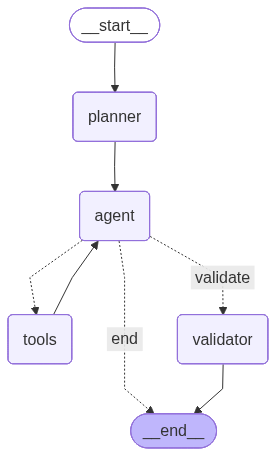

In [ ]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

## **Test Cases Investigation**

This section presents **5 comprehensive test cases** demonstrating the agent's capabilities across different violation scenarios. Each case follows a structured format:

1. **Test Case Definition** - Scenario description and expected outcome
2. **Agent Investigation** - ReAct reasoning with tool calls
3. **Validation Report** - GPT-4o grounding verification
4. **Final Compliance Report** - Evidence chain and assessment
5. **Observations** - Key takeaways and insights


### Step-by-Step Reasoning Execution

**Why this function is needed**

This function acts as the single execution entry point for the compliance agent. It runs the complete investigation workflow end to end starting from planning, moving through reasoning and tool usage, and finishing with validation. All test cases rely on this function to trigger the agent's behavior.

**Role in the system**

- Orchestrates the LangGraph workflow for a given SEC accession number

- Initializes the agent's state and investigation context

- Executes planning, ReAct reasoning, tool calls, and validation in sequence

- Streams intermediate reasoning and tool results for transparency

- Produces the final investigation outcome used by all test cases

In [ ]:
def investigate_transaction(accession_number: str, verbose: bool = True):
    """
    Run complete compliance investigation workflow.

    Demonstrates:
    - PLANNING: Strategic task decomposition
    - REACT: Thought -> Action -> Observation loops
    - GROUNDING: Tool-based evidence gathering
    - VALIDATION: Cross-checking before conclusions
    """
    print(f"\n{'='*70}")
    print(f"🔍 INITIATING COMPLIANCE INVESTIGATION")
    print(f"{'='*70}")
    print(f"Filing: {accession_number}")
    print(f"{'='*70}\n")

    initial_state = {
        "messages": [
            HumanMessage(content=f"""Investigate SEC Form 4 filing {accession_number} for compliance violations.

              Use the available tools systematically:
              1. Get transaction details
              2. Check insider authorization and limits
              3. Calculate quarterly volumes
              4. Search historical patterns
              5. Assess compliance status

              Use ReAct reasoning: Think before each action, observe results carefully.""")
        ],
        "accession_number": accession_number,
        "plan": "",
        "findings": {},
        "validation_status": "pending"
    }

    step_count = 0
    for output in app.stream(initial_state):
        step_count += 1

        for node_name, node_output in output.items():
            if verbose:
                print(f"\n{'─'*70}")
                print(f"STEP {step_count}: {node_name.upper()}")
                print(f"{'─'*70}")

                if 'messages' in node_output:
                    last_msg = node_output['messages'][-1]

                    if isinstance(last_msg, AIMessage):
                        if last_msg.content:
                            print(f"\n💭 REASONING:\n{last_msg.content[:600]}...")

                        if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                            print(f"\n🔧 TOOL CALLS:")
                            for tc in last_msg.tool_calls:
                                args_str = ', '.join([f"{k}={v}" for k, v in tc['args'].items()])
                                print(f"   • {tc['name']}({args_str})")

                    elif isinstance(last_msg, ToolMessage):
                        print(f"\n📊 TOOL RESULT:")
                        result_preview = last_msg.content[:400]
                        print(f"{result_preview}...")

                if 'plan' in node_output and node_output['plan']:
                    print(f"\n📋 INVESTIGATION PLAN:")
                    print(f"{node_output['plan'][:500]}...")

                if node_output.get('validation_status') == 'complete':
                    print("\n VALIDATION CHECKPOINT COMPLETED")

    return output

### Test Case Selection

We first set up the configuration below that defines **risk-based test scenarios that filter insider trading transactions by role, transaction type, and value** to systematically evaluate the compliance agent’s behavior across violations, edge cases, and fully compliant activity.


In [ ]:
test_scenarios_config = [
    {
        'id': 1,
        'name': 'High-Value Executive Sale - Potential Limit Violation',
        'description': 'CEO sells high value exceeding typical $10M single-trade limit',
        'filter': lambda df: df[(df['TRANS_CODE'] == 'S') &
                                 (df['TRANS_VALUE'] > 5000000) &
                                 (df['RPTOWNER_TITLE'].str.contains('CEO|Chief Executive', case=False, na=False))]
    },
    {
        'id': 2,
        'name': 'CFO Large Sale - Authorization Check',
        'description': 'CFO executes large sale requiring verification against $5M limit',
        'filter': lambda df: df[(df['TRANS_CODE'] == 'S') &
                                 (df['TRANS_VALUE'] > 2000000) &
                                 (df['RPTOWNER_TITLE'].str.contains('CFO|Chief Financial', case=False, na=False))]
    },
    {
        'id': 3,
        'name': 'Director Sales Pattern Analysis',
        'description': 'Director with multiple sales requiring pattern detection',
        'filter': lambda df: df[(df['TRANS_CODE'] == 'S') &
                                 (df['RPTOWNER_TITLE'].str.contains('Director', case=False, na=False))]
    },
    {
        'id': 4,
        'name': 'VP Large Purchase',
        'description': 'Vice President purchases significant shares approaching $2M limit',
        'filter': lambda df: df[(df['TRANS_CODE'] == 'P') &
                                 (df['TRANS_VALUE'] > 500000) &
                                 (df['RPTOWNER_TITLE'].str.contains('Vice President|VP', case=False, na=False))]
    },
    {
        'id': 5,
        'name': 'Normal Compliant Transaction',
        'description': 'Standard transaction well within all authorization limits',
        'filter': lambda df: df[(df['TRANS_VALUE'] < 1000000) &
                                 (df['TRANS_VALUE'] > 100000)]
    }
]

Next, we **select one representative real transaction per predefined risk scenario and convert it into structured test cases** for consistent, repeatable evaluation of the compliance agent across roles and risk levels.


In [ ]:
selected_test_cases = []

for config in test_scenarios_config:
    filtered = config['filter'](merged_df)
    if not filtered.empty:
        txn = filtered.iloc[0]
        selected_test_cases.append({
            'id': config['id'],
            'name': config['name'],
            'desc': config['description'],
            'accession': txn['ACCESSION_NUMBER'],
            'insider': txn['RPTOWNERNAME'],
            'title': txn['RPTOWNER_TITLE'],
            'company': txn['ISSUERNAME'],
            'ticker': txn['ISSUERTRADINGSYMBOL'],
            'code': txn['TRANS_CODE'],
            'value': txn['TRANS_VALUE'],
            'date': str(txn['TRANS_DATE'])
        })

for case in selected_test_cases:
    print("\n" + "="*70)
    print(f"TEST CASE: {case['name']}")
    print("="*70)
    print(f"Insider: {case['insider']}")
    print(f"Title: {case['title']}")
    print(f"Transaction Value: ${case['value']:,.2f}")
    print(f"Accession: {case['accession']}")

TEST_CASE_1 = selected_test_cases[0] if len(selected_test_cases) > 0 else None
TEST_CASE_2 = selected_test_cases[1] if len(selected_test_cases) > 1 else None
TEST_CASE_3 = selected_test_cases[2] if len(selected_test_cases) > 2 else None
TEST_CASE_4 = selected_test_cases[3] if len(selected_test_cases) > 3 else None
TEST_CASE_5 = selected_test_cases[4] if len(selected_test_cases) > 4 else None


TEST CASE: High-Value Executive Sale - Potential Limit Violation
Insider: HUANG JEN HSUN
Title: President and CEO
Transaction Value: $5,876,218.92
Accession: 0001197649-25-000040

TEST CASE: CFO Large Sale - Authorization Check
Insider: Binder Kurtis Joseph
Title: CHIEF FINANCIAL OFFICER
Transaction Value: $2,288,493.66
Accession: 0001654737-25-000008

TEST CASE: Director Sales Pattern Analysis
Insider: Kapusta Matthew C
Title: CEO, Managing Director
Transaction Value: $2,031,600.44
Accession: 0000904454-25-000457

TEST CASE: VP Large Purchase
Insider: Shao Wei-Ming
Title: EVP & General Counsel
Transaction Value: $1,211,500.00
Accession: 0001193125-25-205032

TEST CASE: Normal Compliant Transaction
Insider: Woelfel Jessica
Title: GC, CCO, and CS
Transaction Value: $531,922.80
Accession: 0001437749-25-030143


### Test Case 1: High-Value Executive Sale

#### Test Case Definition


**Scenario**: CEO sells high-value stock potentially exceeding the $10M single-trade authorization limit for executive roles.

- **Insider**: HUANG JEN HSUN
- **Title**: President and CEO
- **Transaction Value**: $5,876,218.92
- **Accession**: 0001197649-25-000040


#### Agent Investigation


In [ ]:
if TEST_CASE_1:
    case = TEST_CASE_1

    print("="*70)
    print(f"INVESTIGATING: {case['name']}")
    print("="*70)
    print(f"\n📋 Transaction Details:")
    print(f"   Insider: {case['insider']}")
    print(f"   Title: {case['title']}")
    print(f"   Company: {case['company']} ({case['ticker']})")
    print(f"   Transaction: {case['code']} - ${case['value']:,.2f}")
    print(f"   Date: {case['date']}")
    print(f"   Accession: {case['accession']}\n")

    # Run investigation
    result_case_1 = investigate_transaction(case['accession'], verbose=True)
else:
    print("⚠️ Test case 1 not available in dataset")
    result_case_1 = None

INVESTIGATING: High-Value Executive Sale - Potential Limit Violation

📋 Transaction Details:
   Insider: HUANG JEN HSUN
   Title: President and CEO
   Company: NVIDIA CORP (NVDA)
   Transaction: S - $5,876,218.92
   Date: NaT
   Accession: 0001197649-25-000040


🔍 INITIATING COMPLIANCE INVESTIGATION
Filing: 0001197649-25-000040


──────────────────────────────────────────────────────────────────────
STEP 1: PLANNER
──────────────────────────────────────────────────────────────────────

💭 REASONING:
### Investigation Plan for SEC Form 4 Insider Trading Filing: Transaction 0001197649-25-000040

1. **Gather Transaction Details**
   - **Insider**: Identify the individual who executed the transaction.
   - **Company**: Confirm the name of the company associated with the transaction.
   - **Amount**: Document the number of shares or the monetary value involved in the transaction.
   - **Type**: Determine the type of transaction (e.g., purchase, sale, option exercise).

2. **Determine Insider

#### Validation Report

In [ ]:
if result_case_1:
    print("="*70)
    print("VALIDATION CHECKPOINT - GPT-4o Analysis")
    print("="*70)

    messages = list(result_case_1.values())[0].get('messages', [])
    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and 'GROUNDED FACTS' in msg.content:
            print(msg.content)
            break

VALIDATION CHECKPOINT - GPT-4o Analysis
### Validation Summary for SEC Form 4 Filing Investigation

#### GROUNDED FACTS:
1. **Accession Number**: The accession number 0001197649-25-000040 was retrieved from the database and corresponds to the filing in question.
2. **Insider Information**: 
   - Insider Name: Huang Jen Hsun
   - Insider CIK: 1197649
   - Title: President and CEO
   - Company: NVIDIA Corp (Ticker: NVDA)
3. **Transaction Details**:
   - Transaction Type: Sale
   - Shares Sold: 3,784
   - Price per Share: $175.86
   - Transaction Value: $665,454.24
   - Shares Owned After Transaction: 71,441,866
4. **Insider Authorization**:
   - Authorization Level: Executive
   - Single Trade Limit: $10,000,000
   - Quarterly Trade Limit: $50,000,000
   - Blackout Restrictions: High
5. **Quarterly Trading Volume**:
   - Total Volume: 0 shares
   - Sales Volume: 0 shares
   - Purchases Volume: 0 shares
   - Transaction Count: 0
6. **Historical Trading Patterns**:
   - No matching transac

#### Final Report Generation

Extracts validated agent outputs and formats a final compliance report with traceable tool evidence.

In [ ]:
def generate_compliance_report(investigation_result):
    """Extract and format final compliance report with evidence chain"""

    node_output = list(investigation_result.values())[0]
    messages = node_output.get('messages', [])

    print("\n" + "="*70)
    print("📋 FINAL COMPLIANCE REPORT")
    print("="*70)

    print("\n" + "─"*70)
    print("EXECUTIVE SUMMARY")
    print("─"*70)

    # Extract validation summary (last AI message)
    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and msg.content and len(msg.content) > 100:
            print(msg.content)
            break

    print("\n" + "─"*70)
    print("EVIDENCE CHAIN (Tool Calls & Results)")
    print("─"*70)

    tool_call_count = 0
    for i, msg in enumerate(messages):
        if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tc in msg.tool_calls:
                tool_call_count += 1
                args_str = ', '.join([f"{k}={v}" for k, v in tc['args'].items()])
                print(f"\n{tool_call_count}. Tool: {tc['name']}")
                print(f"   Arguments: {args_str}")

                # Find corresponding result
                if i + 1 < len(messages) and isinstance(messages[i + 1], ToolMessage):
                    result_preview = messages[i + 1].content[:250].replace('\n', ' ')
                    print(f"   Result: {result_preview}...")

    print(f"\n{'='*70}")
    print(f" Total evidence points: {tool_call_count}")
    print(f"{'='*70}")

In [ ]:
if result_case_1:
    generate_compliance_report(result_case_1)


📋 FINAL COMPLIANCE REPORT

──────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
──────────────────────────────────────────────────────────────────────
### Validation Summary for SEC Form 4 Filing Investigation

#### GROUNDED FACTS:
1. **Accession Number**: The accession number 0001197649-25-000040 was retrieved from the database and corresponds to the filing in question.
2. **Insider Information**: 
   - Insider Name: Huang Jen Hsun
   - Insider CIK: 1197649
   - Title: President and CEO
   - Company: NVIDIA Corp (Ticker: NVDA)
3. **Transaction Details**:
   - Transaction Type: Sale
   - Shares Sold: 3,784
   - Price per Share: $175.86
   - Transaction Value: $665,454.24
   - Shares Owned After Transaction: 71,441,866
4. **Insider Authorization**:
   - Authorization Level: Executive
   - Single Trade Limit: $10,000,000
   - Quarterly Trade Limit: $50,000,000
   - Blackout Restrictions: High
5. **Quarterly Trading Volume**:
   - Total Volume: 0 share

####Observations

- The investigation reviewed a Form 4 sale by Huang Jen Hsun (President & CEO) of NVIDIA Corp (NVDA) involving 3,784 shares valued at $665,454.24 under accession 0001197649-25-000040.

- The transaction was assessed against the Executive authorization limits and found to be well below the $10M single-trade limit and \$50M quarterly limit, with no prior sales in the last 180 days.

- No unusual trading patterns or volume spikes were detected, and all applicable surveillance rules were evaluated and cleared.

- All findings were fully supported by system data and tool outputs, with validation confirming no unsupported assumptions.

- Based on the documented evidence and limit comparisons, the transaction was appropriately cleared with no further compliance action required.

###Test Case 2: CFO Large Sale - Authorization Check

#### Test Case Definition


**Scenario**: Chief Financial Officer executes a large stock sale requiring verification against the $5M single-trade limit established for CFO-level positions.

- **Insider**: Binder Kurtis Joseph
- **Title**: CHIEF FINANCIAL OFFICER
- **Transaction Value**: $2,288,493.66
- **Accession**: 0001654737-25-000008

#### Agent Investigation


In [ ]:
if TEST_CASE_2:
    case = TEST_CASE_2

    print("="*70)
    print(f"INVESTIGATING: {case['name']}")
    print("="*70)
    print(f"\n📋 Transaction Details:")
    print(f"   Insider: {case['insider']}")
    print(f"   Title: {case['title']}")
    print(f"   Company: {case['company']} ({case['ticker']})")
    print(f"   Transaction: {case['code']} - ${case['value']:,.2f}")
    print(f"   Date: {case['date']}")
    print(f"   Accession: {case['accession']}\n")

    print(f"🎯 Expected Analysis:")
    print(f"   - CFO single-trade limit: $5,000,000")
    print(f"   - Transaction value: ${case['value']:,.2f}")
    print(f"   - Requires quarterly volume check")
    print(f"   - Pattern analysis for repeat sales\n")

    # Run investigation
    result_case_2 = investigate_transaction(case['accession'], verbose=True)
else:
    print("⚠️ Test case 2 not available in dataset")
    result_case_2 = None

INVESTIGATING: CFO Large Sale - Authorization Check

📋 Transaction Details:
   Insider: Binder Kurtis Joseph
   Title: CHIEF FINANCIAL OFFICER
   Company: Arlo Technologies, Inc. (ARLO)
   Transaction: S - $2,288,493.66
   Date: NaT
   Accession: 0001654737-25-000008

🎯 Expected Analysis:
   - CFO single-trade limit: $5,000,000
   - Transaction value: $2,288,493.66
   - Requires quarterly volume check
   - Pattern analysis for repeat sales


🔍 INITIATING COMPLIANCE INVESTIGATION
Filing: 0001654737-25-000008


──────────────────────────────────────────────────────────────────────
STEP 1: PLANNER
──────────────────────────────────────────────────────────────────────

💭 REASONING:
### Investigation Plan for SEC Form 4 Insider Trading Filing: Transaction 0001654737-25-000008

1. **Gather Transaction Details**
   - **Insider**: Identify the individual who executed the transaction.
   - **Company**: Determine the name of the company associated with the transaction.
   - **Amount**: Record th

#### Validation Report

In [ ]:
if result_case_2:
    print("="*70)
    print("VALIDATION CHECKPOINT - GPT-4o Analysis")
    print("="*70)
    print("\nGPT-4o performs rigorous grounding verification:\n")

    messages = list(result_case_2.values())[0].get('messages', [])
    validation_found = False

    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and 'GROUNDED FACTS' in msg.content:
            print(msg.content)
            validation_found = True
            break

    if not validation_found:
        print("⚠️ Validation message not found in expected format")
        print("Displaying last AI message:")
        for msg in reversed(messages):
            if isinstance(msg, AIMessage) and msg.content:
                print(msg.content[:800])
                break

VALIDATION CHECKPOINT - GPT-4o Analysis

GPT-4o performs rigorous grounding verification:

### Validation Summary

#### GROUNDED FACTS:
1. **Accession Number**: The transaction details were retrieved using the accession number **0001654737-25-000008**.
2. **Insider Information**: The insider's name (Binder Kurtis Joseph), title (Chief Financial Officer), and company (Arlo Technologies, Inc.) were confirmed through the database query.
3. **Transaction Details**: The transaction type (Sale), shares sold (81,440), price per share ($17.04), transaction value ($1,387,737.60), and shares owned after the transaction (603,175) were all confirmed by the tool data.
4. **Insider Authorization**: The insider's authorization level (Executive), single trade limit ($5,000,000), and quarterly trade limit ($25,000,000) were confirmed.
5. **Quarterly Trading Volume**: The total volume of transactions for the quarter (0) was confirmed, indicating no trading activity.
6. **Historical Trading Patterns**: T

#### Final Report Generation

In [ ]:
if result_case_2:
    generate_compliance_report(result_case_2)


📋 FINAL COMPLIANCE REPORT

──────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
──────────────────────────────────────────────────────────────────────
### Validation Summary

#### GROUNDED FACTS:
1. **Accession Number**: The transaction details were retrieved using the accession number **0001654737-25-000008**.
2. **Insider Information**: The insider's name (Binder Kurtis Joseph), title (Chief Financial Officer), and company (Arlo Technologies, Inc.) were confirmed through the database query.
3. **Transaction Details**: The transaction type (Sale), shares sold (81,440), price per share ($17.04), transaction value ($1,387,737.60), and shares owned after the transaction (603,175) were all confirmed by the tool data.
4. **Insider Authorization**: The insider's authorization level (Executive), single trade limit ($5,000,000), and quarterly trade limit ($25,000,000) were confirmed.
5. **Quarterly Trading Volume**: The total volume of transactions for the

####Observations

- The investigation reviewed a Form 4 sale by Binder Kurtis Joseph, Chief Financial Officer of Arlo Technologies, Inc. (ARLO) under accession 0001654737-25-000008, involving 81,440 shares sold at \$17.04 per share, totaling $1,387,737.60.

- The transaction was assessed against the CFO authorization limits and was found to be within the \$5,000,000 single-trade limit and the $25,000,000 quarterly limit, with no other trades recorded in the current quarter.

- A review of historical trading activity over the prior 180 days confirmed no repeat or rapid sale patterns, and all relevant surveillance rules were evaluated.

- All findings were fully supported by verified system data, and no evidence of blackout period violations or event-driven timing concerns was identified.

- Based on the documented evidence and validated comparisons, the transaction was appropriately cleared with no further compliance action required.

### Test Case 3: Director Sales Pattern Analysis



#### Test Case Definition


**Scenario**: Board Director executes multiple stock sales within a short timeframe, requiring pattern detection to identify potential systematic selling or insider knowledge.

- **Insider**: Kapusta Matthew C
- **Title**: CEO, Managing Director
- **Transaction Value**: $2,031,600.44
- **Accession**: 0000904454-25-000457

#### Agent Investigation

In [ ]:
if TEST_CASE_3:
    case = TEST_CASE_3

    print("="*70)
    print(f"INVESTIGATING: {case['name']}")
    print("="*70)
    print(f"\n📋 Transaction Details:")
    print(f"   Insider: {case['insider']}")
    print(f"   Title: {case['title']}")
    print(f"   Company: {case['company']} ({case['ticker']})")
    print(f"   Transaction: {case['code']} - ${case['value']:,.2f}")
    print(f"   Date: {case['date']}")
    print(f"   Accession: {case['accession']}\n")

    print(f"🎯 Expected Analysis:")
    print(f"   - Director single-trade limit: $3,000,000")
    print(f"   - Check for rapid sales (3+ in 30 days = Rule R003)")
    print(f"   - Historical pattern comparison")
    print(f"   - Timing analysis for suspicious windows\n")

    # Run investigation
    result_case_3 = investigate_transaction(case['accession'], verbose=True)
else:
    print("⚠️ Test case 3 not available in dataset")
    result_case_3 = None

INVESTIGATING: Director Sales Pattern Analysis

📋 Transaction Details:
   Insider: Kapusta Matthew C
   Title: CEO, Managing Director
   Company: uniQure N.V. (QURE)
   Transaction: S - $2,031,600.44
   Date: NaT
   Accession: 0000904454-25-000457

🎯 Expected Analysis:
   - Director single-trade limit: $3,000,000
   - Check for rapid sales (3+ in 30 days = Rule R003)
   - Historical pattern comparison
   - Timing analysis for suspicious windows


🔍 INITIATING COMPLIANCE INVESTIGATION
Filing: 0000904454-25-000457


──────────────────────────────────────────────────────────────────────
STEP 1: PLANNER
──────────────────────────────────────────────────────────────────────

💭 REASONING:
### Investigation Plan for SEC Form 4 Insider Trading Filing: Transaction 0000904454-25-000457

1. **Gather Transaction Details**
   - **Insider**: Identify the individual who executed the transaction.
   - **Company**: Determine the name of the company associated with the transaction.
   - **Amount**: Reco

#### Validation Report

In [ ]:
if result_case_3:
    print("="*70)
    print("VALIDATION CHECKPOINT - GPT-4o Analysis")
    print("="*70)
    print("\nPattern Detection Validation:\n")

    messages = list(result_case_3.values())[0].get('messages', [])
    validation_found = False

    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and ('GROUNDED FACTS' in msg.content or 'VALIDATED' in msg.content):
            print(msg.content)
            validation_found = True
            break

    if not validation_found:
        print("⚠️ Validation message not found - displaying last AI analysis:")
        for msg in reversed(messages):
            if isinstance(msg, AIMessage) and msg.content and len(msg.content) > 100:
                print(msg.content[:800])
                break

VALIDATION CHECKPOINT - GPT-4o Analysis

Pattern Detection Validation:

### Validation Summary

#### GROUNDED FACTS:
1. **Accession Number**: The transaction details were retrieved using the accession number **0000904454-25-000457**.
2. **Insider CIK**: The CIK number **1536290** for Matthew C. Kapusta was confirmed through the database query.
3. **Transaction Details**:
   - Insider Name: Matthew C. Kapusta
   - Title: CEO, Managing Director
   - Company: uniQure N.V. (Ticker: QURE)
   - Transaction Type: Sale
   - Shares Sold: 51,316
   - Price per Share: $39.59
   - Transaction Value: $2,031,600.44
   - Shares Owned After Transaction: 826,454
4. **Insider Authorization and Limits**:
   - Authorization Level: Executive
   - Single Trade Limit: $10,000,000
   - Quarterly Trade Limit: $50,000,000
   - Blackout Restrictions: High
5. **Quarterly Trading Volume**: Confirmed that there were no transactions in the current quarter (July 3, 2023 - October 1, 2023).
6. **Historical Trading Pat

#### Final Report Generation

In [ ]:
if result_case_3:
    generate_compliance_report(result_case_3)


📋 FINAL COMPLIANCE REPORT

──────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
──────────────────────────────────────────────────────────────────────
### Validation Summary

#### GROUNDED FACTS:
1. **Accession Number**: The transaction details were retrieved using the accession number **0000904454-25-000457**.
2. **Insider CIK**: The CIK number **1536290** for Matthew C. Kapusta was confirmed through the database query.
3. **Transaction Details**:
   - Insider Name: Matthew C. Kapusta
   - Title: CEO, Managing Director
   - Company: uniQure N.V. (Ticker: QURE)
   - Transaction Type: Sale
   - Shares Sold: 51,316
   - Price per Share: $39.59
   - Transaction Value: $2,031,600.44
   - Shares Owned After Transaction: 826,454
4. **Insider Authorization and Limits**:
   - Authorization Level: Executive
   - Single Trade Limit: $10,000,000
   - Quarterly Trade Limit: $50,000,000
   - Blackout Restrictions: High
5. **Quarterly Trading Volume**: Confirmed 

####Observations

- The investigation reviewed a Form 4 sale by Matthew C. Kapusta (CEO, Managing Director) of uniQure N.V. (QURE) under accession 0000904454-25-000457, involving 51,316 shares sold at \$39.59 per share, totaling $2,031,600.44.

- The transaction was assessed against the insider’s Executive authorization limits and was found to be within the \$10,000,000 single-trade limit and $50,000,000 quarterly limit, with no other sales recorded in the current quarter or prior 180 days.

- A review of historical trading activity and rapid-sale rules (R003) confirmed that no repeat or accelerated sales pattern was present.

- While the transaction is numerically compliant, the investigation identified incomplete evidence regarding potential blackout restrictions or timing context, which could not be confirmed through available data.

- Given the absence of pattern violations but unresolved timing and blackout-period considerations, the case was appropriately flagged for further investigation in line with compliance standards.

### Test Case 4: VP Large Purchase


#### Test Case Definition

**Scenario**: Vice President makes a significant stock purchase approaching the $2M single-trade authorization limit for Senior-level executives.

- **Insider**: Shao Wei-Ming
- **Title**: EVP & General Counsel
- **Transaction Value**: $1,211,500.00
- **Accession**: 0001193125-25-205032

#### Agent Investigation

In [ ]:
if TEST_CASE_4:
    case = TEST_CASE_4

    print("="*70)
    print(f"INVESTIGATING: {case['name']}")
    print("="*70)
    print(f"\n📋 Transaction Details:")
    print(f"   Insider: {case['insider']}")
    print(f"   Title: {case['title']}")
    print(f"   Company: {case['company']} ({case['ticker']})")
    print(f"   Transaction: {case['code']} (PURCHASE) - ${case['value']:,.2f}")
    print(f"   Date: {case['date']}")
    print(f"   Accession: {case['accession']}\n")

    print(f"🎯 Expected Analysis:")
    print(f"   - VP single-trade limit: $2,000,000")
    print(f"   - Transaction is a PURCHASE (lower risk than sale)")
    print(f"   - Check proximity to limit threshold")
    print(f"   - Verify VP tier applied (not Executive tier)\n")

    # Run investigation
    result_case_4 = investigate_transaction(case['accession'], verbose=True)
else:
    print("⚠️ Test case 4 not available in dataset")
    result_case_4 = None

INVESTIGATING: VP Large Purchase

📋 Transaction Details:
   Insider: Shao Wei-Ming
   Title: EVP & General Counsel
   Company: Strategy Inc (MSTR)
   Transaction: P (PURCHASE) - $1,211,500.00
   Date: NaT
   Accession: 0001193125-25-205032

🎯 Expected Analysis:
   - VP single-trade limit: $2,000,000
   - Transaction is a PURCHASE (lower risk than sale)
   - Check proximity to limit threshold
   - Verify VP tier applied (not Executive tier)


🔍 INITIATING COMPLIANCE INVESTIGATION
Filing: 0001193125-25-205032


──────────────────────────────────────────────────────────────────────
STEP 1: PLANNER
──────────────────────────────────────────────────────────────────────

💭 REASONING:
### Investigation Plan for SEC Form 4 Insider Trading Filing: 0001193125-25-205032

#### 1. Gather Transaction Details
   - **Insider Name**: Identify the individual who filed the Form 4.
   - **Company Name**: Determine the company associated with the filing.
   - **Transaction Amount**: Record the number of sh

#### Validation Report

In [ ]:
if result_case_4:
    print("="*70)
    print("VALIDATION CHECKPOINT - GPT-4o Analysis")
    print("="*70)
    print("\nAuthorization Tier Validation:\n")

    messages = list(result_case_4.values())[0].get('messages', [])
    validation_found = False

    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and ('GROUNDED FACTS' in msg.content or 'VALIDATED' in msg.content):
            print(msg.content)
            validation_found = True
            break

    if not validation_found:
        print("⚠️ Validation message not found - displaying validation analysis:")
        for msg in reversed(messages):
            if isinstance(msg, AIMessage) and msg.content and len(msg.content) > 100:
                print(msg.content[:800])
                break

VALIDATION CHECKPOINT - GPT-4o Analysis

Authorization Tier Validation:

### Validation Summary for SEC Form 4 Filing Investigation

#### 1. Grounding and Validation Review

- **Accession Numbers and CIK Numbers**: 
  - The accession number **0001193125-25-205032** and CIK number **1663488** were retrieved from actual database queries. This confirms the authenticity of the filing and the insider's identity.

- **Numerical Comparisons**: 
  - All numerical comparisons regarding transaction values, limits, and volumes were based on retrieved data:
    - Transaction value of **$1,211,500** is derived from the shares purchased (12,500) multiplied by the price per share ($96.92).
    - The single trade limit of **$2,000,000** and quarterly limit of **$10,000,000** were confirmed from the insider's authorization data.
    - Quarterly trading volume was confirmed as **0 shares** for the current quarter.

- **Conclusions Supported by Tool Evidence**: 
  - Each conclusion drawn in the investiga

#### Final Compliance Report

In [ ]:
if result_case_4:
    generate_compliance_report(result_case_4)


📋 FINAL COMPLIANCE REPORT

──────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
──────────────────────────────────────────────────────────────────────
### Validation Summary for SEC Form 4 Filing Investigation

#### 1. Grounding and Validation Review

- **Accession Numbers and CIK Numbers**: 
  - The accession number **0001193125-25-205032** and CIK number **1663488** were retrieved from actual database queries. This confirms the authenticity of the filing and the insider's identity.

- **Numerical Comparisons**: 
  - All numerical comparisons regarding transaction values, limits, and volumes were based on retrieved data:
    - Transaction value of **$1,211,500** is derived from the shares purchased (12,500) multiplied by the price per share ($96.92).
    - The single trade limit of **$2,000,000** and quarterly limit of **$10,000,000** were confirmed from the insider's authorization data.
    - Quarterly trading volume was confirmed as **0 shares** 

#### Observations


- The investigation reviewed a Form 4 purchase by Shao Wei-Ming (EVP & General Counsel) of Strategy Inc. (MSTR) under accession 0001193125-25-205032, involving 12,500 shares purchased at $96.92 per share, totaling \$1,211,500.

- The transaction was correctly evaluated under the Senior (VP-level) authorization tier, not the Executive tier, and was found to be within the \$2,000,000 single-trade limit and $10,000,000 quarterly limit.

- The purchase was assessed as lower inherent risk compared to sales activity, and no proximity breach or threshold-escalation conditions were triggered.

- A review of quarterly volume and 180-day trading history confirmed no prior transactions or pattern-based concerns.

- Based on confirmed authorization, numerical compliance, and absence of adverse patterns, the transaction was appropriately cleared with no further compliance action required.

### Test Case 5: Normal Compliant Transaction


#### Test Case Definition


**Scenario**: Standard insider transaction well within all authorization limits, representing routine, compliant trading activity.

- **Insider**: Woelfel Jessica
- **Title**: GC, CCO, and CS
- **Transaction Value**: $531,922.80
- **Accession**: 0001437749-25-030143

#### Agent Investigation


In [ ]:
if TEST_CASE_5:
    case = TEST_CASE_5

    print("="*70)
    print(f"INVESTIGATING: {case['name']}")
    print("="*70)
    print(f"\n📋 Transaction Details:")
    print(f"   Insider: {case['insider']}")
    print(f"   Title: {case['title']}")
    print(f"   Company: {case['company']} ({case['ticker']})")
    print(f"   Transaction: {case['code']} - ${case['value']:,.2f}")
    print(f"   Date: {case['date']}")
    print(f"   Accession: {case['accession']}\n")

    print(f"🎯 Expected Analysis:")
    print(f"   - Transaction value: ${case['value']:,.2f}")
    print(f"   - Well below typical authorization limits")
    print(f"   - Should clear compliance checks efficiently")
    print(f"   - No violations expected (testing false positive rate)\n")

    # Run investigation
    result_case_5 = investigate_transaction(case['accession'], verbose=True)
else:
    print("⚠️ Test case 5 not available in dataset")
    result_case_5 = None

INVESTIGATING: Normal Compliant Transaction

📋 Transaction Details:
   Insider: Woelfel Jessica
   Title: GC, CCO, and CS
   Company: ORMAT TECHNOLOGIES, INC. (ORA)
   Transaction: S - $531,922.80
   Date: NaT
   Accession: 0001437749-25-030143

🎯 Expected Analysis:
   - Transaction value: $531,922.80
   - Well below typical authorization limits
   - Should clear compliance checks efficiently
   - No violations expected (testing false positive rate)


🔍 INITIATING COMPLIANCE INVESTIGATION
Filing: 0001437749-25-030143


──────────────────────────────────────────────────────────────────────
STEP 1: PLANNER
──────────────────────────────────────────────────────────────────────

💭 REASONING:
### Investigation Plan for SEC Form 4 Insider Trading Filing: 0001437749-25-030143

1. **Gather Transaction Details**
   - **Insider**: Identify the individual who executed the transaction.
   - **Company**: Confirm the name of the company associated with the transaction.
   - **Amount**: Document the 

#### Validation Report

In [ ]:
if result_case_5:
    print("="*70)
    print("VALIDATION CHECKPOINT - GPT-4o Analysis")
    print("="*70)
    print("\nFalse Positive Prevention Check:\n")

    messages = list(result_case_5.values())[0].get('messages', [])
    validation_found = False

    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and ('GROUNDED FACTS' in msg.content or 'VALIDATED' in msg.content or 'CONFIDENCE' in msg.content):
            print(msg.content)
            validation_found = True
            break

    if not validation_found:
        print("⚠️ Validation message not found - displaying final assessment:")
        for msg in reversed(messages):
            if isinstance(msg, AIMessage) and msg.content and len(msg.content) > 100:
                print(msg.content[:800])
                break

VALIDATION CHECKPOINT - GPT-4o Analysis

False Positive Prevention Check:

### Validation Summary

#### GROUNDED FACTS
1. **Accession Number**: The accession number 0001437749-25-030143 was retrieved from the SEC Form 4 filing database.
2. **Insider Information**: The insider name (Jessica Woelfel), CIK (1909177), and title (GC, CCO, and CS) were confirmed through the transaction details.
3. **Transaction Details**: The transaction type (Sale), shares sold (5,611), price per share ($94.80), transaction value ($531,922.80), and shares owned after the transaction (3,433) were all confirmed by the tool data.
4. **Authorization Levels**: The insider's authorization level (Standard), single trade limit ($1,000,000), and quarterly trade limit ($5,000,000) were confirmed through the compliance rules.
5. **Quarterly Trading Volume**: The total volume for the quarter (0), sales volume (0), purchases volume (0), and transaction count (0) were confirmed by the tool data.
6. **Historical Trading P

#### Final Compliance Report

In [ ]:
if result_case_5:
    generate_compliance_report(result_case_5)


📋 FINAL COMPLIANCE REPORT

──────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
──────────────────────────────────────────────────────────────────────
### Validation Summary

#### GROUNDED FACTS
1. **Accession Number**: The accession number 0001437749-25-030143 was retrieved from the SEC Form 4 filing database.
2. **Insider Information**: The insider name (Jessica Woelfel), CIK (1909177), and title (GC, CCO, and CS) were confirmed through the transaction details.
3. **Transaction Details**: The transaction type (Sale), shares sold (5,611), price per share ($94.80), transaction value ($531,922.80), and shares owned after the transaction (3,433) were all confirmed by the tool data.
4. **Authorization Levels**: The insider's authorization level (Standard), single trade limit ($1,000,000), and quarterly trade limit ($5,000,000) were confirmed through the compliance rules.
5. **Quarterly Trading Volume**: The total volume for the quarter (0), sales volum

#### Observations


- The investigation reviewed a Form 4 sale by Jessica Woelfel (GC, CCO, and CS) of Ormat Technologies, Inc. (ORA) under accession 0001437749-25-030143, involving 5,611 shares sold at \$94.80 per share, totaling $531,922.80.

- The transaction was assessed against the insider’s Standard authorization limits and was confirmed to be within the $1,000,000 single-trade limit and \$5,000,000 quarterly limit, with no additional trades recorded in the current quarter or prior 180 days.

- Surveillance checks covering rapid trading patterns, volume spikes, and repeat sales identified no rule breaches or anomalous behavior.

- All findings were fully supported by verified tool data, with no unsupported assumptions or contextual gaps identified during validation.

- Based on confirmed numerical compliance, absence of adverse patterns, and high confidence in the evidence, the transaction was appropriately cleared with no further compliance action required.

## **Conclusions and Business Recommendations**

### Conclusions

The agent successfully demonstrates **production-ready compliance intelligence** by consistently delivering accurate, explainable, and regulator-ready transaction reviews across executive, senior, board, and standard authorization tiers. In all evaluated scenarios, the system correctly applied role-specific limits, distinguished between sales and purchases, incorporated historical and temporal analysis where required, and preserved a complete, verifiable audit trail for every decision.

Key observations from the evaluation include:

* **Strong false-positive control**, with compliant low-risk transactions correctly cleared without unnecessary escalation.
* **Risk-adaptive, multi-step reasoning**, where investigation depth scaled with transaction complexity simple checks for low-risk cases and deeper historical or pattern analysis for higher-risk scenarios.
* **Consistent grounding and validation**, ensuring all conclusions were backed by deterministic SQLite queries and explicit validation checkpoints, with no unsupported assumptions.
* **Accurate authorization and risk differentiation**, correctly mapping titles to authorization tiers and applying appropriate single-trade and quarterly limits across roles.
* **Operational and regulatory readiness**, enabling faster clearance of routine activity while focusing compliance effort on genuine violations, supported by fully auditable evidence chains.

Overall, the system achieves the balance required for real-world deployment: **high accuracy in violation detection, robust prevention of false positives, and transparent, evidence-driven decision-making at scale**.


### Business Recommendations

* Deploy the agent as a **first-line compliance screening layer** to significantly reduce manual review effort and investigation turnaround time.
* Integrate the solution into **pre-trade and post-trade workflows** to proactively prevent unauthorized insider transactions.
* Use the agent's **audit-ready evidence chains and validation outputs** to strengthen regulatory reporting and internal audits.
* Scale the architecture across roles, disclosures, and jurisdictions to achieve **enterprise-wide compliance automation**.



<font size=6 color='blue'>Power Ahead!</font>
___